In [1]:
import moabb
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import P300
from hoda import HODA, MLSVD
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.analysis.plotting import paired_plot, meta_analysis_plot, summary_plot
from sklearn.base import BaseEstimator, ClassifierMixin
from toeplitzlda.classification import ToeplitzLDA
from sklearn.svm import SVC
from moabb.analysis.meta_analysis import (  # noqa: E501
    compute_dataset_statistics,
    find_significant_differences,
)

In [2]:
sfreq = 16*2
paradigm = P300(resample=sfreq, tmin=0, tmax=0.7, fmin=0.1, fmax=16)
datasets = [
    BNCI2014008(),
    #BNCI2014009()
    #EPFLP300()
]
evaluation = WithinSessionEvaluation(
    paradigm=paradigm, datasets=datasets,
    suffix="examples", overwrite=True,
)

In [3]:

class ToeplitzLDAWrapper(BaseEstimator, ClassifierMixin):

    def fit(self, X, y=None):
        n_epochs, n_channels, n_samples = X.shape
        self.tlda_ = ToeplitzLDA(n_channels=n_channels, data_is_channel_prime=False)
        X = X.reshape(n_epochs, -1)
        return self.tlda_.fit(X, y)

    def decision_function(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.decision_function(X)

    def predict(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict(X)

    def predict_proba(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict_proba(X)

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC

pipelines = dict()

pipelines['tHODA+LDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    HODA(max_iter=64, tol=1e-6,
         shrinkage='oas', initialize='svd',
         toeplitz=(1,), rank=5),
    FunctionTransformer(lambda X: X.reshape((X.shape[0],-1))),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
    #SVC(kernel='rbf', C=1)
)

pipelines['tLDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    ToeplitzLDAWrapper()
)

In [17]:
import tensorly as tl
#try:
#    tl.set_backend('jax')
#except AttributeError:
#    tl.set_backend('jax')

In [18]:
results = evaluation.process(pipelines )

008-2014-WithinSession:   0%|                             | 0/8 [00:00<?, ?it/s]/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/moabb/analysis/results.py:22: RuntimeWarning: You are probably using a classifier with a lambda function as an attribute. Lambda functions can only be identified by memory address which MOABB does not consider. To avoid issues you can use named functions defined using the def keyword instead.
  warnings.warn(
/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/moabb/analysis/results.py:22: RuntimeWarning: You are probably using a classifier with a lambda function as an attribute. Lambda functions can only be identified by memory address which MOABB does not consider. To avoid issues you can use named functions defined using the def keyword instead.
  warnings.warn(
008-2014-WithinSession:  12%|██▋                  | 1/8 [00:14<01:39, 14.28s/it]/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/moabb/analysis/results.py:22:

In [8]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.834047,1.998968,4200.0,1,session_0,8,1,008-2014,tHODA+LDA
1,0.822451,0.981621,4200.0,2,session_0,8,1,008-2014,tHODA+LDA
2,0.877663,1.646654,4200.0,3,session_0,8,1,008-2014,tHODA+LDA
3,0.810037,1.834220,4200.0,4,session_0,8,1,008-2014,tHODA+LDA
4,0.862214,1.102305,4200.0,5,session_0,8,1,008-2014,tHODA+LDA
5,0.877896,2.410774,4200.0,6,session_0,8,1,008-2014,tHODA+LDA
6,0.864306,1.438404,4200.0,7,session_0,8,1,008-2014,tHODA+LDA
7,0.954837,1.504759,4200.0,8,session_0,8,1,008-2014,tHODA+LDA
8,0.846761,0.130080,4200.0,1,session_0,8,1,008-2014,tLDA
9,0.820367,0.116855,4200.0,2,session_0,8,1,008-2014,tLDA


/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


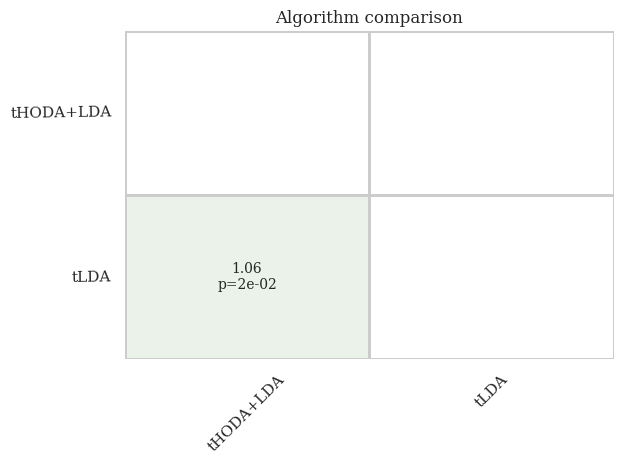

In [9]:
stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)

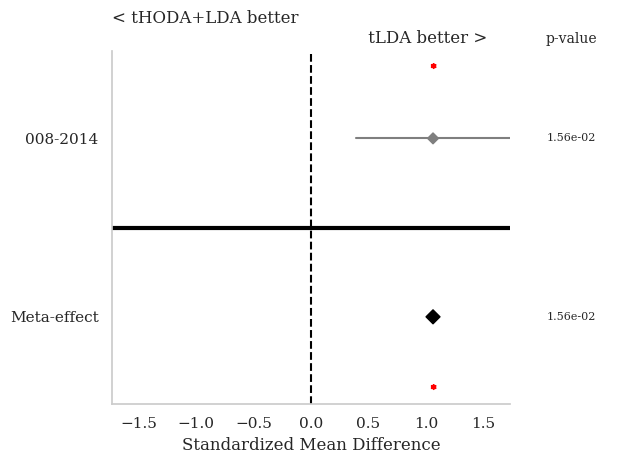

In [10]:
_=meta_analysis_plot(stats, "tLDA", "tHODA+LDA")

/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


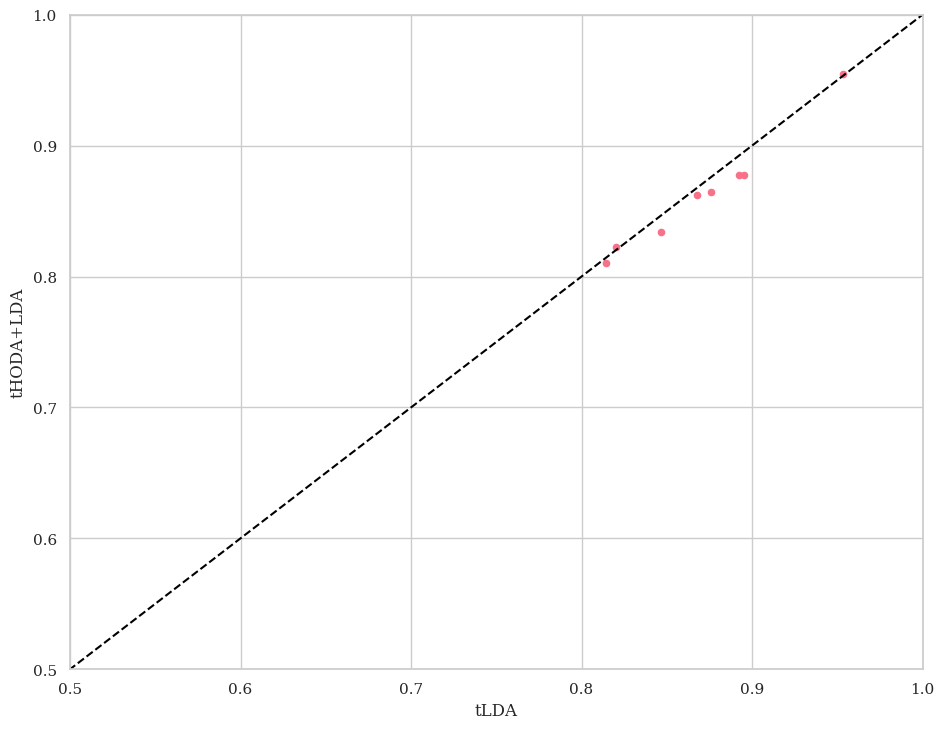

In [11]:
_=paired_plot(results, "tLDA", "tHODA+LDA")